In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from model import CACRT
from losses import CompetingRisksLoss, CIndexMetric, IntegratedBrierScore
from evaluation import full_evaluation

from baselines import run_all_baselines
from cross_validation import run_cross_validation


# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load and Prepare UNOS Data


def load_and_prepare_data(filepath):
   
    df = pd.read_parquet(filepath)
    
    DONOR_FEATURES = [
        'AGE_DON', 'GENDER_DON', 'WGT_KG_DON_CALC',
        'HGT_CM_DON_CALC', 'BMI_DON_CALC', 'CREAT_DON',
        'HYPERTENS_DUR_DON', 'HIST_DIABETES_DON',
        'NON_HRT_DON', 'ECD_DONOR',
        'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0',
    ]
    
    RECIPIENT_FEATURES = [
        'AGE', 'GENDER', 'WGT_KG_CALC', 'HGT_CM_CALC',
        'END_BMI_CALC', 'END_CPRA_DETAIL', 'FUNC_STAT_TRR',
        'DIAL_VINT_YEARS', 'NUM_PREV_TX', 'NPKID',
        'DIAB_2.0', 'DIAB_3.0', 'DIAB_4.0',
    ]
    
    MATCH_FEATURES = [
        'HLAMIS', 'COLD_ISCH_KI', 'PUMP_KI',
    ]
    
    # =========================================================================
    # Validate columns exist
    # =========================================================================
    all_features = DONOR_FEATURES + RECIPIENT_FEATURES + MATCH_FEATURES
    missing = [f for f in all_features if f not in df.columns]
    if missing:
        print(f" Missing columns: {missing}")
        print(f" Available columns: {list(df.columns)}")
        raise ValueError(f"Missing columns: {missing}")
    
    # =========================================================================
    # Encode competing events
    # =========================================================================
    # event: 0 = censored, 1 = graft failure, 2 = DWFG
    event = np.where(
        df['GSTATUS_KI'] == 0, 0,                    # Censored
        np.where(df['DWFG_KI'] == 1, 2, 1)           # DWFG=2, graft failure=1
    )
    durations = df['GTIME_YEARS'].values.astype('float32')
    
    # Extract feature matrices
    X_donor = df[DONOR_FEATURES].values.astype('float32')
    X_recip = df[RECIPIENT_FEATURES].values.astype('float32')
    X_match = df[MATCH_FEATURES].values.astype('float32')
    
    return X_donor, X_recip, X_match, durations, event, \
           DONOR_FEATURES, RECIPIENT_FEATURES, MATCH_FEATURES



In [3]:
# Data Splitting and Preprocessing

def prepare_splits(X_donor, X_recip, X_match, durations, events):
    
    #Split into train/val/test (70/15/15) with stratification by event type
    #Standardize features (fit on train only)
    #Discretize survival times into bins
    
    # --- Stratified split ---
    idx = np.arange(len(durations))
    idx_train, idx_temp, ev_train, ev_temp = train_test_split(
        idx, events, test_size=0.3, stratify=events, random_state=42
    )
    idx_val, idx_test, ev_val, ev_test = train_test_split(
        idx_temp, ev_temp, test_size=0.5, stratify=ev_temp, random_state=42
    )
    
    # --- Standardize (fit on train) ---
    scaler_donor = StandardScaler()
    scaler_recip = StandardScaler()
    scaler_match = StandardScaler()
    
    X_d_train = scaler_donor.fit_transform(X_donor[idx_train])
    X_d_val = scaler_donor.transform(X_donor[idx_val])
    X_d_test = scaler_donor.transform(X_donor[idx_test])
    
    X_r_train = scaler_recip.fit_transform(X_recip[idx_train])
    X_r_val = scaler_recip.transform(X_recip[idx_val])
    X_r_test = scaler_recip.transform(X_recip[idx_test])
    
    X_m_train = scaler_match.fit_transform(X_match[idx_train])
    X_m_val = scaler_match.transform(X_match[idx_val])
    X_m_test = scaler_match.transform(X_match[idx_test])
    
    dur_train = durations[idx_train]
    dur_val = durations[idx_val]
    dur_test = durations[idx_test]
    
    ev_train = events[idx_train]
    ev_val = events[idx_val]
    ev_test = events[idx_test]
    
    # --- Discretize time into bins ---
    NUM_TIME_BINS = 100
    # Create equidistant grid from 0 to max observed time
    time_grid = np.linspace(0, dur_train.max(), NUM_TIME_BINS + 1)[1:]  # bin edges
    
    # Digitize: map continuous times to bin indices
    dur_train_disc = np.digitize(dur_train, time_grid).astype('int64')
    dur_val_disc = np.digitize(dur_val, time_grid).astype('int64')
    dur_test_disc = np.digitize(dur_test, time_grid).astype('int64')
    
    # Clamp to valid range [0, NUM_TIME_BINS-1]
    dur_train_disc = np.clip(dur_train_disc, 0, NUM_TIME_BINS - 1)
    dur_val_disc = np.clip(dur_val_disc, 0, NUM_TIME_BINS - 1)
    dur_test_disc = np.clip(dur_test_disc, 0, NUM_TIME_BINS - 1)
    
    data = {
        'train': {
            'donor': torch.FloatTensor(X_d_train),
            'recip': torch.FloatTensor(X_r_train),
            'match': torch.FloatTensor(X_m_train),
            'durations': torch.LongTensor(dur_train_disc),
            'events': torch.LongTensor(ev_train),
            'durations_raw': dur_train,
        },
        'val': {
            'donor': torch.FloatTensor(X_d_val),
            'recip': torch.FloatTensor(X_r_val),
            'match': torch.FloatTensor(X_m_val),
            'durations': torch.LongTensor(dur_val_disc),
            'events': torch.LongTensor(ev_val),
            'durations_raw': dur_val,
        },
        'test': {
            'donor': torch.FloatTensor(X_d_test),
            'recip': torch.FloatTensor(X_r_test),
            'match': torch.FloatTensor(X_m_test),
            'durations': torch.LongTensor(dur_test_disc),
            'events': torch.LongTensor(ev_test),
            'durations_raw': dur_test,
        },
        'time_grid': time_grid,
        'num_time_bins': NUM_TIME_BINS,
        'scalers': (scaler_donor, scaler_recip, scaler_match),
    }
    
    # Print summary
    for split_name in ['train', 'val', 'test']:
        ev = data[split_name]['events'].numpy()
        n = len(ev)
        print(f"{split_name:5s}: n={n:6d} | "
              f"censored={np.sum(ev==0):5d} ({np.mean(ev==0)*100:.1f}%) | "
              f"graft_fail={np.sum(ev==1):5d} ({np.mean(ev==1)*100:.1f}%) | "
              f"DWFG={np.sum(ev==2):5d} ({np.mean(ev==2)*100:.1f}%)")
    
    return data

In [4]:
# Create DataLoaders

class SurvivalDataset(Dataset):
    """Custom dataset for competing risks survival data"""
    def __init__(self, donor, recip, match, durations, events):
        self.donor = donor
        self.recip = recip
        self.match = match
        self.durations = durations
        self.events = events
    
    def __len__(self):
        return len(self.durations)
    
    def __getitem__(self, idx):
        return (self.donor[idx], self.recip[idx], self.match[idx],
                self.durations[idx], self.events[idx])


def create_dataloaders(data, batch_size=512):
    train_ds = SurvivalDataset(
        data['train']['donor'], data['train']['recip'], data['train']['match'],
        data['train']['durations'], data['train']['events']
    )
    val_ds = SurvivalDataset(
        data['val']['donor'], data['val']['recip'], data['val']['match'],
        data['val']['durations'], data['val']['events']
    )
    test_ds = SurvivalDataset(
        data['test']['donor'], data['test']['recip'], data['test']['match'],
        data['test']['durations'], data['test']['events']
    )
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False,
                            num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size * 2, shuffle=False,
                             num_workers=0, pin_memory=True)
    
    return train_loader, val_loader, test_loader

In [5]:
#Training Loop

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_nll = 0
    total_rank = 0
    n_batches = 0
    
    for donor, recip, match, dur, evt in loader:
        donor = donor.to(device)
        recip = recip.to(device)
        match = match.to(device)
        dur = dur.to(device)
        evt = evt.to(device)
        
        optimizer.zero_grad()
        pmf, cif, surv = model(donor, recip, match)
        loss, nll, rank = criterion(pmf, cif, surv, dur, evt)
        
        loss.backward()
        # Gradient clipping — important for transformer stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_nll += nll.item()
        total_rank += rank.item()
        n_batches += 1
    
    return total_loss / n_batches, total_nll / n_batches, total_rank / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0
    total_nll = 0
    total_rank = 0
    n_batches = 0
    
    all_cif = []
    all_dur = []
    all_evt = []
    
    for donor, recip, match, dur, evt in loader:
        donor = donor.to(device)
        recip = recip.to(device)
        match = match.to(device)
        dur = dur.to(device)
        evt = evt.to(device)
        
        pmf, cif, surv = model(donor, recip, match)
        loss, nll, rank = criterion(pmf, cif, surv, dur, evt)
        
        total_loss += loss.item()
        total_nll += nll.item()
        total_rank += rank.item()
        n_batches += 1
        
        all_cif.append(cif.cpu())
        all_dur.append(dur.cpu())
        all_evt.append(evt.cpu())
    
    all_cif = torch.cat(all_cif, dim=0)
    all_dur = torch.cat(all_dur, dim=0)
    all_evt = torch.cat(all_evt, dim=0)
    
    # Compute C-index for each cause (on a sample for speed)
    c_graft = CIndexMetric.compute(all_cif, all_dur, all_evt, cause=1)
    c_dwfg = CIndexMetric.compute(all_cif, all_dur, all_evt, cause=2)
    
    """n_eval = min(15000, len(all_dur))
    sample_idx = np.random.choice(len(all_dur), n_eval, replace=False)
    
    c_graft = CIndexMetric.compute(
        all_cif[sample_idx], all_dur[sample_idx], all_evt[sample_idx], cause=1
    )
    c_dwfg = CIndexMetric.compute(
        all_cif[sample_idx], all_dur[sample_idx], all_evt[sample_idx], cause=2
    )"""
    
    avg_loss = total_loss / n_batches
    
    return avg_loss, total_nll / n_batches, total_rank / n_batches, c_graft, c_dwfg




In [6]:
def train_model(model, train_loader, val_loader, config, device):
    """
    Full training loop with early stopping, LR scheduling, and logging.
    """
    criterion = CompetingRisksLoss(
        alpha=config['alpha'],
        sigma=config['sigma'],
        num_risks=config['num_risks']
    )
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )
    
    # Early stopping
    best_val_loss = float('inf')
    best_val_c_graft = 0
    patience_counter = 0
    best_model_state = None
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_nll': [], 'val_nll': [],
        'train_rank': [], 'val_rank': [],
        'val_c_graft': [], 'val_c_dwfg': [],
        'lr': []
    }
    
    print(f"\n{'='*80}")
    print(f"Training CACRTransformer")
    print(f"{'='*80}")
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'C_graft':>8} | {'C_DWFG':>8} | {'LR':>10} | {'Status':>10}")
    print(f"{'-'*80}")
    
    for epoch in range(config['max_epochs']):
        # Train
        train_loss, train_nll, train_rank = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_nll, val_rank, c_graft, c_dwfg = evaluate(
            model, val_loader, criterion, device
        )
        
        # LR scheduling
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_nll'].append(train_nll)
        history['val_nll'].append(val_nll)
        history['train_rank'].append(train_rank)
        history['val_rank'].append(val_rank)
        history['val_c_graft'].append(c_graft)
        history['val_c_dwfg'].append(c_dwfg)
        history['lr'].append(current_lr)
        
        # Early stopping (based on validation C-index for graft failure)
        status = ""
        if c_graft > best_val_c_graft:
            best_val_c_graft = c_graft
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            status = "★"
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"\nEarly stopping at epoch {epoch+1} "
                      f"(best C_graft: {best_val_c_graft:.4f})")
                break
        
        if (epoch + 1) % 5 == 0 or status:
            print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                  f"{c_graft:8.4f} | {c_dwfg:8.4f} | {current_lr:10.6f} | {status:>10}")
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)
    
    return model, history

In [7]:
# Visualization Functions

def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss curves
    axes[0, 0].plot(history['train_loss'], label='Train', alpha=0.8)
    axes[0, 0].plot(history['val_loss'], label='Val', alpha=0.8)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # NLL vs Ranking loss
    axes[0, 1].plot(history['train_nll'], label='NLL (train)', alpha=0.8)
    axes[0, 1].plot(history['train_rank'], label='Rank (train)', alpha=0.8)
    axes[0, 1].set_title('Loss Components (Train)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # C-index
    axes[1, 0].plot(history['val_c_graft'], label='Graft Failure', color='#e74c3c')
    axes[1, 0].plot(history['val_c_dwfg'], label='DWFG', color='#3498db')
    axes[1, 0].set_title('Validation C-index (cause-specific)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate
    axes[1, 1].plot(history['lr'], color='#2ecc71')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
def plot_cif_curves(model, data, device, n_patients=5):
    """Plot individual patient CIF curves for both competing risks."""
    model.eval()
    
    # Pick random test patients
    n_test = len(data['test']['donor'])
    idx = np.random.choice(n_test, n_patients, replace=False)
    
    with torch.no_grad():
        donor = data['test']['donor'][idx].to(device)
        recip = data['test']['recip'][idx].to(device)
        match = data['test']['match'][idx].to(device)
        
        pmf, cif, surv = model(donor, recip, match)
        cif = cif.cpu().numpy()
        surv = surv.cpu().numpy()
    
    time_grid = data['time_grid']
    events = data['test']['events'][idx].numpy()
    durs = data['test']['durations'][idx].numpy()
    
    fig, axes = plt.subplots(1, n_patients, figsize=(5 * n_patients, 4), sharey=True)
    if n_patients == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        # CIF for graft failure (cause 1)
        ax.plot(time_grid, cif[i, 0, :], color='#e74c3c', linewidth=2,
                label='Graft Failure')
        ax.fill_between(time_grid, 0, cif[i, 0, :], alpha=0.15, color='#e74c3c')
        
        # CIF for DWFG (cause 2)
        ax.plot(time_grid, cif[i, 1, :], color='#3498db', linewidth=2,
                label='DWFG')
        ax.fill_between(time_grid, cif[i, 0, :],
                       cif[i, 0, :] + cif[i, 1, :], alpha=0.15, color='#3498db')
        
        # Mark actual event
        event_names = {0: 'Censored', 1: 'Graft Fail', 2: 'DWFG'}
        event_colors = {0: 'gray', 1: '#e74c3c', 2: '#3498db'}
        t_idx = min(durs[i], len(time_grid) - 1)
        ax.axvline(x=time_grid[t_idx], color=event_colors[events[i]],
                  linestyle='--', alpha=0.7)
        ax.set_title(f'Patient {idx[i]}\n({event_names[events[i]]})', fontsize=10)
        ax.set_xlabel('Time')
        if i == 0:
            ax.set_ylabel('Cumulative Incidence')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
    
    plt.suptitle('Patient-Level Competing Risks CIF', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('cif_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

In [9]:
def plot_attention_heatmap(model, data, device, donor_features, recip_features):
    """Visualize cross-attention weights for interpretability."""
    model.eval()
    
    # Run a small batch to get attention weights
    with torch.no_grad():
        donor = data['test']['donor'][:32].to(device)
        recip = data['test']['recip'][:32].to(device)
        match = data['test']['match'][:32].to(device)
        
        _ = model(donor, recip, match)
        attn_weights = model.get_cross_attention_weights()
    
    # Average attention weights over batch and heads
    # Last cross-attention layer
    d2r = attn_weights[-1]['donor_to_recip'].mean(dim=0).numpy()
    r2d = attn_weights[-1]['recip_to_donor'].mean(dim=0).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Donor → Recipient attention
    sns.heatmap(d2r, ax=axes[0], cmap='YlOrRd',
                xticklabels=recip_features, yticklabels=donor_features,
                annot=False, fmt='.2f')
    axes[0].set_title('Donor attending to Recipient features')
    axes[0].set_xlabel('Recipient Features')
    axes[0].set_ylabel('Donor Features')
    
    # Recipient → Donor attention
    sns.heatmap(r2d, ax=axes[1], cmap='YlOrRd',
                xticklabels=donor_features, yticklabels=recip_features,
                annot=False, fmt='.2f')
    axes[1].set_title('Recipient attending to Donor features')
    axes[1].set_xlabel('Donor Features')
    axes[1].set_ylabel('Recipient Features')
    
    plt.suptitle('Cross-Attention Weights (interpretability)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

Configuration and Main Execution

In [10]:
# =============================================================================
# MODEL AND TRAINING CONFIGURATION
# =============================================================================
CONFIG = {
    
    'data_path': 'C:/Users/olf3ph/Music/dd/New folder/graft_preproc_encod.parquet',  
    
    # --- Model architecture ---
    'd_model': 32,           # Embedding dimension per feature
    'n_heads': 8,            # Attention heads (must divide d_model)
    'n_self_layers': 2,      # Self-attention layers per stream
    'n_cross_layers': 1,     # Cross-attention layers
    'd_ff': 256,             # FFN hidden dim
    'dropout': 0.3,         # Dropout rate
    'num_risks': 2,          # Graft failure + DWFG
    'num_time_bins': 100,    # Time discretization granularity
    
    # --- Training ---
    'batch_size': 1024,       # 143k / 512 ≈ 280 steps per epoch
    'lr': 7e-4,              # Initial learning rate
    'weight_decay': 5e-4,    # L2 regularization
    'max_epochs': 300,       # Maximum training epochs
    'patience': 25,          # Early stopping patience
    
    # --- Loss ---
    'alpha': 0.3,            # Ranking loss weight (0 = pure NLL)
    'sigma': 0.01,            # Ranking loss smoothness
}

In [ ]:
def main():
    """
    Execution pipeline
    """
    # Load data
    print("Loading and preparing data...")
    print("-" * 60)
    X_donor, X_recip, X_match, durations, events, \
        donor_feats, recip_feats, match_feats = load_and_prepare_data(CONFIG['data_path'])
    
    n_donor = X_donor.shape[1]
    n_recip = X_recip.shape[1]
    n_match = X_match.shape[1]
    
    print(f"\nFeature groups:")
    print(f"  Donor:     {n_donor} features → {donor_feats}")
    print(f"  Recipient: {n_recip} features → {recip_feats}")
    print(f"  Match:     {n_match} features → {match_feats}")
    print(f"  Total:     {n_donor + n_recip + n_match} features")
    print(f"\nEvent distribution:")
    for evt_val, evt_name in [(0, 'Censored'), (1, 'Graft Failure'), (2, 'DWFG')]:
        count = np.sum(events == evt_val)
        print(f"  {evt_name}: {count} ({count/len(events)*100:.1f}%)")
    
    # Prepare splits
    print("Splitting and standardizing...")
    print("-" * 60)
    data = prepare_splits(X_donor, X_recip, X_match, durations, events)
    
    # Create dataloaders
    train_loader, val_loader, test_loader = create_dataloaders(
        data, batch_size=CONFIG['batch_size']
    )
    
    # Initialize model
    print(f"\n{'-'*60}")
    print(" Initializing CACRT...")
    print("-" * 60)
    model = CACRT(
        n_donor_features=n_donor,
        n_recip_features=n_recip,
        n_match_features=n_match,
        d_model=CONFIG['d_model'],
        n_heads=CONFIG['n_heads'],
        n_self_layers=CONFIG['n_self_layers'],
        n_cross_layers=CONFIG['n_cross_layers'],
        d_ff=CONFIG['d_ff'],
        num_risks=CONFIG['num_risks'],
        num_time_bins=CONFIG['num_time_bins'],
        dropout=CONFIG['dropout']
    ).to(device)
    
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}")
    print(f"  Device: {device}")
    
    # Train
    print(f"\n{'-'*60}")
    print("Training...")
    print("-" * 60)
    model, history = train_model(model, train_loader, val_loader, CONFIG, device)
    
    # Evaluate on test set
    print(f"\n{'-'*60}")
    print("Final evaluation on test set...")
    print("-" * 60)
    criterion = CompetingRisksLoss(
        alpha=CONFIG['alpha'], sigma=CONFIG['sigma'], num_risks=CONFIG['num_risks']
    )
    test_loss, test_nll, test_rank, test_c_graft, test_c_dwfg = evaluate(
        model, test_loader, criterion, device
    )
    print(f"\n  Test Loss:       {test_loss:.4f}")
    print(f"  Test C_graft:    {test_c_graft:.4f}")
    print(f"  Test C_DWFG:     {test_c_dwfg:.4f}")
    
    # Visualizations
    print(f"\n{'-'*60}")
    print("Generating visualizations...")
    print("-" * 60)
    plot_training_history(history)
    plot_cif_curves(model, data, device)
    plot_attention_heatmap(model, data, device, donor_feats, recip_feats)
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CONFIG,
        'history': history,
        'feature_names': {
            'donor': donor_feats,
            'recipient': recip_feats,
            'match': match_feats
        }
    }, 'cacr_transformer_best.pt')
    print("\nModel saved to cacr_transformer_best.pt")
    
    return model, history, data


Loading and preparing data...
------------------------------------------------------------

Feature groups:
  Donor:     13 features → ['AGE_DON', 'GENDER_DON', 'WGT_KG_DON_CALC', 'HGT_CM_DON_CALC', 'BMI_DON_CALC', 'CREAT_DON', 'HYPERTENS_DUR_DON', 'HIST_DIABETES_DON', 'NON_HRT_DON', 'ECD_DONOR', 'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0']
  Recipient: 13 features → ['AGE', 'GENDER', 'WGT_KG_CALC', 'HGT_CM_CALC', 'END_BMI_CALC', 'END_CPRA_DETAIL', 'FUNC_STAT_TRR', 'DIAL_VINT_YEARS', 'NUM_PREV_TX', 'NPKID', 'DIAB_2.0', 'DIAB_3.0', 'DIAB_4.0']
  Match:     3 features → ['HLAMIS', 'COLD_ISCH_KI', 'PUMP_KI']
  Total:     29 features

Event distribution:
  Censored: 100500 (73.7%)
  Graft Failure: 16574 (12.1%)
  DWFG: 19368 (14.2%)
Splitting and standardizing...
------------------------------------------------------------
train: n= 95509 | censored=70350 (73.7%) | graft_fail=11602 (12.1%) | DWFG=13557 (14.2%)
val  : n= 20466 | censored=15075 (73.7%) | graft_fail= 2486 (12.1%) 

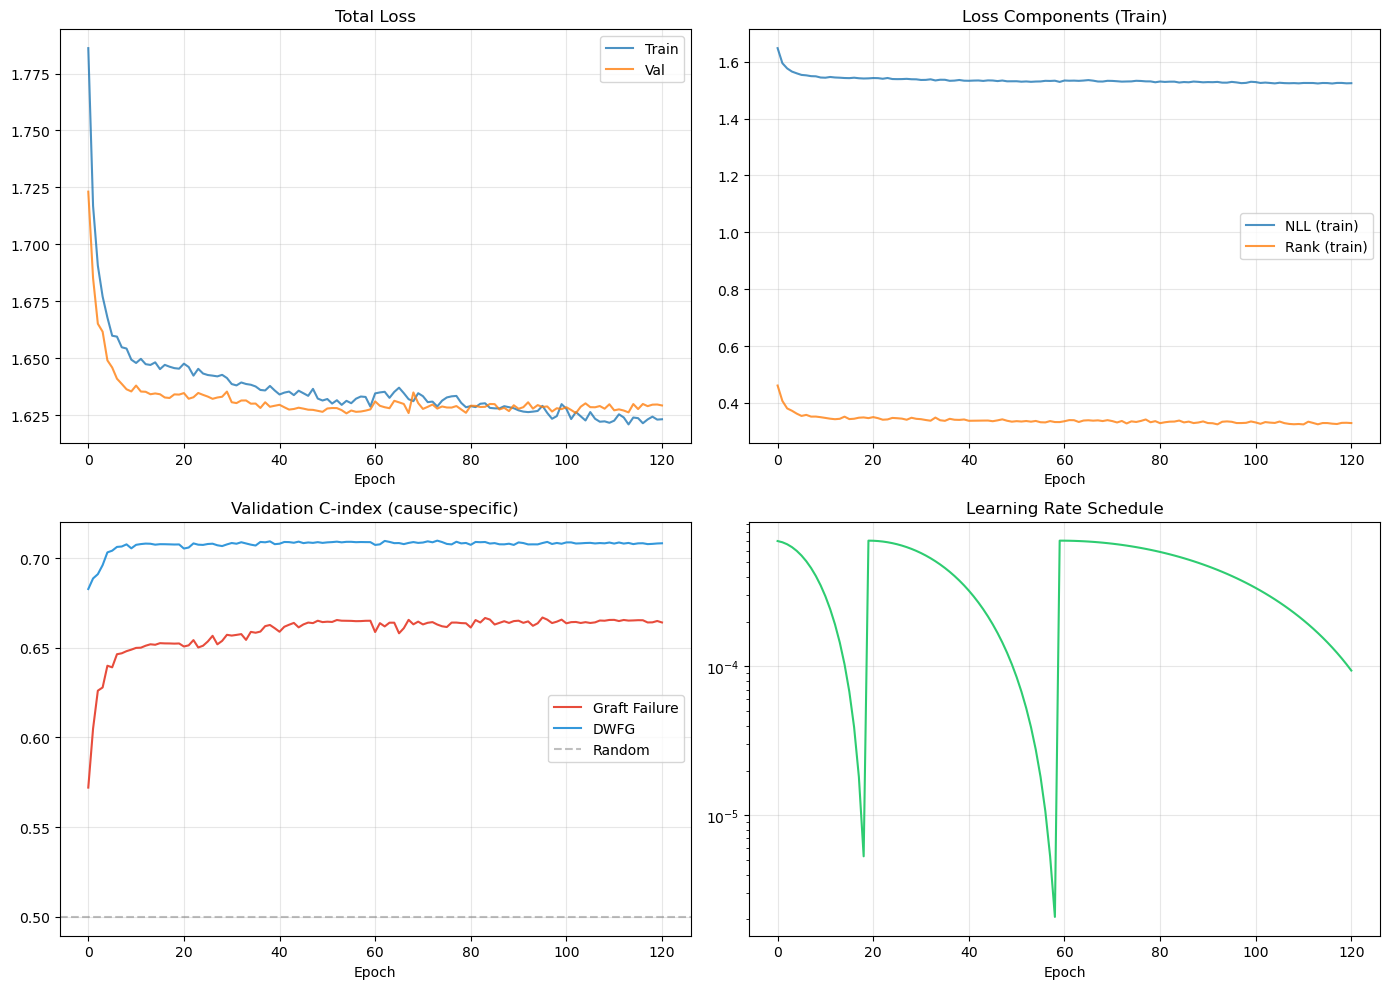

In [ ]:
if __name__ == '__main__':
    model, history, data = main()

In [ ]:
results = full_evaluation(model, data, device, eval_times_years=[1, 3, 5, 10])

In [ ]:
baseline_results = run_all_baselines(data)

In [ ]:
cv_results = run_cross_validation(
    filepath='C:/Users/olf3ph/Music/dd/New folder/graft_preproc_encod.parquet',
    config=CONFIG,
    donor_features=[
        'AGE_DON', 'GENDER_DON', 'WGT_KG_DON_CALC',
        'HGT_CM_DON_CALC', 'BMI_DON_CALC', 'CREAT_DON',
        'HYPERTENS_DUR_DON', 'HIST_DIABETES_DON',
        'NON_HRT_DON', 'ECD_DONOR',
        'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0',
    ],
    recip_features=[
        'AGE', 'GENDER', 'WGT_KG_CALC', 'HGT_CM_CALC',
        'END_BMI_CALC', 'END_CPRA_DETAIL', 'FUNC_STAT_TRR',
        'DIAL_VINT_YEARS', 'NUM_PREV_TX', 'NPKID',
        'DIAB_2.0', 'DIAB_3.0', 'DIAB_4.0',
    ],
    match_features=[
        'HLAMIS', 'COLD_ISCH_KI', 'PUMP_KI',
    ],
    n_folds=5
)